# Original Split Sanity Check and Token-Signal Analysis

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

In [ ]:
# ── SET YOUR PATH HERE ───────────────────────────────
BASE = Path("C:/Users/rabia/Documents/Thesis/original_split")
# ─────────────────────────────────────────────────────
DATA_DIR_token = BASE / "token_level"
OUT_DIR = BASE / "sanity_checks" / "token_sanity_results"
FIG_DIR = BASE / "sanity_checks" / "token_sanity_results" / "figures"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODEL_LABELS = {
    "llava": "LLaVA-OV-7B",
    "qwen3b": "Qwen2.5-VL-3B",
    "qwen7b": "Qwen2.5-VL-7B",
}

MODEL_ORDER_DEFAULT = ["LLaVA-OV-7B", "Qwen2.5-VL-3B", "Qwen2.5-VL-7B"]

MODEL_COLORS = {
    "LLaVA-OV-7B": "#B8CBAA",
    "Qwen2.5-VL-3B": "#AFC4E8",
    "Qwen2.5-VL-7B": "#D69C6D",
}

DOMAIN_ORDER = ["Animals", "Chess Pieces", "Flags", "Game Boards", "Logos"]

OUTPUT_PATTERN = "*_original_model_outputs.csv"
SIGNAL_PATTERN = "*_original_numeric_signal.csv"

if "DOMAIN_ORDER" not in globals():
    DOMAIN_ORDER = ["Animals", "Chess Pieces", "Flags", "Game Boards", "Logos"]

if "REPORT_COLORS" not in globals():
    REPORT_COLORS = {
        "bg": "#FFFFFF",
        "panel": "#FFFFFF",
        "text": "#111111",
        "muted": "#666666",
        "grid": "#D9D9D9",
        "darkgrey": "#444444",
        "blue": "#AFC4E8",
        "green": "#B8CBAA",
        "orange": "#D69C6D",
        "red": "#C76F5B",
        "brown": "#8B6F5A",
        "grey": "#EAEAEA",
    }

plt.rcParams.update({
    "figure.facecolor": REPORT_COLORS["bg"],
    "axes.facecolor": REPORT_COLORS["panel"],
    "axes.edgecolor": REPORT_COLORS["grid"],
    "axes.labelcolor": REPORT_COLORS["text"],
    "xtick.color": REPORT_COLORS["muted"],
    "ytick.color": REPORT_COLORS["muted"],
    "text.color": REPORT_COLORS["text"],
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})


## 1. Load and stack files

The notebook automatically finds files in `DATA_DIR`, separates model-output files from token-signal files, adds a clean model label, and saves one combined CSV for each file type.

In [3]:
def infer_model_key(path: Path) -> str:
    """Infer model key from filenames such as qwen3b_original_model_outputs.csv."""
    return path.name.split("_original_")[0].lower()


def infer_model_label(path: Path) -> str:
    key = infer_model_key(path)
    return MODEL_LABELS.get(key, key)


def load_and_stack(pattern: str, file_type: str) -> pd.DataFrame:
    paths = sorted(DATA_DIR_token.glob(pattern))
    if not paths:
        raise FileNotFoundError(f"No files found for {pattern!r} in {DATA_DIR_token.resolve()}")

    parts = []
    for path in paths:
        df = pd.read_csv(path)
        df["model"] = infer_model_label(path)
        df["model_key"] = infer_model_key(path)
        df["source_file"] = path.name
        parts.append(df)
        print(f"Loaded {file_type:>7}: {path.name:<45} {df.shape}")

    return pd.concat(parts, ignore_index=True, sort=False)


def normalize_text(value) -> str:
    """Normalize generated or gold text for ID matching."""
    if pd.isna(value):
        return ""

    text = str(value).lower().strip()
    text = re.sub(r"[{}\[\]().,;:!?]", " ", text)
    text = text.replace("_", " ")

    # Remove task-generic words that should not determine correctness.
    text = re.sub(
        r"\b(flag of|the flag of|flag|logo of|the logo of|logo)\b",
        " ",
        text,
    )

    text = re.sub(r"[^a-z0-9]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def extract_number(value):
    """Extract the first integer from a model answer, or return NaN."""
    if pd.isna(value):
        return np.nan

    match = re.search(r"-?\d+", str(value))
    return float(match.group(0)) if match else np.nan


def task_label(type_of_question: str) -> str:
    return "ID" if str(type_of_question).strip().lower() == "id" else "Counting"


def ordered_values(values, preferred_order):
    values = list(pd.Series(values).dropna().unique())
    return [x for x in preferred_order if x in values] + sorted([x for x in values if x not in preferred_order])


def get_model_order(df: pd.DataFrame):
    present = list(pd.Series(df["model"].dropna().unique()))
    return [m for m in MODEL_ORDER_DEFAULT if m in present] + sorted([m for m in present if m not in MODEL_ORDER_DEFAULT])


def save_fig(name: str):
    path = FIG_DIR / f"{name}.png"
    plt.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    print("Saved:", path)


def clean_axes(ax, grid_axis="x"):
    if grid_axis in {"x", "y", "both"}:
        ax.grid(axis=grid_axis, color=REPORT_COLORS["grid"], linewidth=0.85, alpha=0.85)

    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(REPORT_COLORS["grid"])
    ax.spines["bottom"].set_color(REPORT_COLORS["grid"])
    ax.tick_params(axis="x", colors=REPORT_COLORS["muted"])
    ax.tick_params(axis="y", colors=REPORT_COLORS["text"])


In [4]:
outputs_raw = load_and_stack(OUTPUT_PATTERN, "outputs")
signals_raw = load_and_stack(SIGNAL_PATTERN, "signals")
if "pred_num" in signals_raw.columns:
    signals_raw["pred_num"] = signals_raw["pred_num"].astype(float)

MODEL_ORDER = get_model_order(outputs_raw)

raw_outputs_path = OUT_DIR / "original_outputs_all_models_raw_stacked.csv"
raw_signals_path = OUT_DIR / "original_numeric_signals_all_models_raw_stacked.csv"

outputs_raw.to_csv(raw_outputs_path, index=False)
signals_raw.to_csv(raw_signals_path, index=False)

print("\nSaved raw stacked files:")
print(raw_outputs_path)
print(raw_signals_path)

print("\nShapes:")
print("outputs_raw:", outputs_raw.shape)
print("signals_raw:", signals_raw.shape)

Loaded outputs: llava_original_model_outputs.csv              (326, 32)
Loaded outputs: qwen3b_original_model_outputs.csv             (326, 20)
Loaded outputs: qwen7b_original_model_outputs.csv             (326, 20)
Loaded signals: llava_original_numeric_signal.csv             (154, 54)
Loaded signals: qwen3b_original_numeric_signal.csv            (153, 40)
Loaded signals: qwen7b_original_numeric_signal.csv            (154, 40)

Saved raw stacked files:
C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\clean_original_sanity_outputs\original_outputs_all_models_raw_stacked.csv
C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\clean_original_sanity_outputs\original_numeric_signals_all_models_raw_stacked.csv

Shapes:
outputs_raw: (978, 32)
signals_raw: (461, 54)


## sanity check and accuraccy

In [5]:
ACCEPTABLE_ALIASES = {
    # Animals: common semantic aliases
    "african elephant": {"elephant"},
    "dromedary camel": {"camel", "dromedary"},
    "bactrian camel": {"camel"},
    "lion": {"african lion"},
    "tiger": {"bengal tiger"},
    "giraffe": {"giraffa"},

    # Animals: reviewed semantic aliases
    "bison": {"buffalo"},
    "buffalo": {"bison"},
    "caribou": {"reindeer"},
    "puma": {"cougar"},
    "wildebeest": {"gnu"},

    # Logos
    "audi": {"audi car", "audi logo"},
    "mercedes": {"mercedes benz", "mercedes benz logo", "mercedes logo"},
    "volkswagen": {"vw", "volkswagen logo"},
    "adidas": {"adidas logo"},
    "nike": {"nike logo"},

    # Flags
    "europe": {
        "flag of the european union",
        "european union flag",
        "eu flag",
        "flag of eu",
        "the european union",
        "european union",
    },
    "the united states": {
        "flag of the united states of america",
        "united states flag",
        "us flag",
        "usa flag",
        "american flag",
        "the united states of america",
    },
}

BROAD_CATEGORY_ALIASES = {
    # Fine-grained small/shore/wading birds where "bird" is acceptable.
    "avocet": {"bird"},
    "egret": {"bird"},
    "heron": {"bird"},
    "ibis": {"bird"},
    "lapwing": {"bird"},
    "oystercatcher": {"bird"},
    "plover": {"bird"},
    "sandpiper": {"bird"},
    "spoonbill": {"bird"},
    "stilt": {"bird"},
    "stork": {"bird"},

    # Fine-grained antelope/gazelle-type animals.
    "eland": {"antelope"},
    "impala": {"antelope", "gazelle"},
    "kudu": {"antelope"},
    "springbok": {"antelope", "gazelle"},

    # Goat/sheep-like cases.
    "ibex": {"goat"},
    "bighorn sheep": {"goat"},

    # Close visual substitutes.
    "hare": {"rabbit"},
    "rabbit": {"hare"},
    "bobcat": {"lynx"},
    "alpaca": {"llama"},
    "mule": {"donkey"},
}


def alias_id_correct(row) -> bool:
    if row["task"] != "ID":
        return False

    gt = row["gt_text_eval"]
    pred = row["pred_text_eval"]

    if not gt or not pred:
        return False

    if gt == pred:
        return True

    if pred in ACCEPTABLE_ALIASES.get(gt, set()):
        return True

    if gt in ACCEPTABLE_ALIASES.get(pred, set()):
        return True

    return False


def broad_category_id_correct(row) -> bool:
    if row["task"] != "ID":
        return False

    if row.get("topic") != "Animals":
        return False

    gt = row["gt_text_eval"]
    pred = row["pred_text_eval"]

    if not gt or not pred:
        return False

    return pred in BROAD_CATEGORY_ALIASES.get(gt, set())


def prepare_outputs(df: pd.DataFrame) -> pd.DataFrame:
    required = ["type_of_question", "ground_truth", "model_answer"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required output columns: {missing}")

    out = df.copy()

    out["task"] = out["type_of_question"].apply(task_label)
    out["is_counting"] = out["task"].eq("Counting")
    out["is_id"] = out["task"].eq("ID")

    out["gt_num_eval"] = pd.to_numeric(out.get("ground_truth_num", np.nan), errors="coerce")

    if "pred_num" in out.columns:
        out["pred_num_eval"] = pd.to_numeric(out["pred_num"], errors="coerce")
    else:
        out["pred_num_eval"] = np.nan

    missing_pred = out["pred_num_eval"].isna()
    out.loc[missing_pred, "pred_num_eval"] = out.loc[missing_pred, "model_answer"].apply(extract_number)

    out["gt_text_eval"] = out["ground_truth"].apply(normalize_text)
    out["pred_text_eval"] = out["model_answer"].apply(normalize_text)

    out["raw_count_correct"] = (
        out["is_counting"]
        & out["gt_num_eval"].notna()
        & out["pred_num_eval"].notna()
        & out["gt_num_eval"].eq(out["pred_num_eval"])
    )

    out["raw_id_exact_correct"] = (
        out["is_id"]
        & out["gt_text_eval"].eq(out["pred_text_eval"])
    )

    out["raw_correct"] = out["raw_count_correct"] | out["raw_id_exact_correct"]

    out["alias_id_correct"] = out.apply(alias_id_correct, axis=1)
    out["broad_category_id_correct"] = out.apply(broad_category_id_correct, axis=1)

    out["auto_correct_strict"] = out["raw_count_correct"] | out["alias_id_correct"]
    out["auto_correct_broad"] = out["auto_correct_strict"] | out["broad_category_id_correct"]

    out["visual_broader_correct"] = np.where(
        out["is_id"],
        out["auto_correct_broad"],
        out["raw_count_correct"],
    )

    return out


In [6]:
outputs_eval = prepare_outputs(outputs_raw)

processed_outputs_path = OUT_DIR / "original_outputs_all_models_processed.csv"
outputs_eval.to_csv(processed_outputs_path, index=False)

print("\nSaved processed output file:")
print(processed_outputs_path)

display(
    outputs_eval[
        ["model", "task", "topic", "sub_topic", "ground_truth", "model_answer",
         "raw_correct", "auto_correct_strict", "auto_correct_broad"]
    ].head()
)


Saved processed output file:
C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\clean_original_sanity_outputs\original_outputs_all_models_processed.csv


,model,task,topic,sub_topic,ground_truth,model_answer,raw_correct,auto_correct_strict,auto_correct_broad
0,LLaVA-OV-7B,Counting,Flags,flags,6,7,False,False,False
1,LLaVA-OV-7B,ID,Flags,flags,Flag of australia,{Flag of Australia},True,True,True
2,LLaVA-OV-7B,Counting,Flags,flags,3,3,True,True,True
3,LLaVA-OV-7B,ID,Flags,flags,Flag of burundi,{Flag of Burundi},True,True,True
4,LLaVA-OV-7B,Counting,Flags,flags,10,8,False,False,False


In [8]:
def accuracy_summary(df, correct_col, group_cols):
    if isinstance(group_cols, str):
        group_cols = [group_cols]

    return (
        df.groupby(group_cols, dropna=False)
        .agg(
            n=(correct_col, "size"),
            accuracy=(correct_col, "mean"),
        )
        .reset_index()
        .assign(accuracy_pct=lambda x: 100 * x["accuracy"])
    )


def multi_accuracy_summary(df, group_cols):
    metrics = {
        "Raw": "raw_correct",
        "Strict corrected": "auto_correct_strict",
        "Broad visual": "auto_correct_broad",
    }

    parts = []
    for metric_name, col in metrics.items():
        tmp = accuracy_summary(df, col, group_cols)
        tmp["metric"] = metric_name
        parts.append(tmp)

    return pd.concat(parts, ignore_index=True)


overall_acc = multi_accuracy_summary(outputs_eval, ["model"])
task_acc = multi_accuracy_summary(outputs_eval, ["model", "task"])
topic_acc = multi_accuracy_summary(outputs_eval, ["model", "topic"])

subgroup_raw = accuracy_summary(
    outputs_eval,
    "raw_correct",
    ["task", "topic", "model"],
).rename(columns={"accuracy": "raw_acc", "accuracy_pct": "raw_pct"})

subgroup_corrected = accuracy_summary(
    outputs_eval,
    "visual_broader_correct",
    ["task", "topic", "model"],
).rename(columns={"accuracy": "corrected_acc", "accuracy_pct": "corrected_pct"})

subgroup_acc = subgroup_raw.merge(
    subgroup_corrected[["task", "topic", "model", "corrected_acc", "corrected_pct"]],
    on=["task", "topic", "model"],
    how="left",
)

print("\nOverall accuracy:")
display(overall_acc.round(2))

print("\nTask accuracy:")
display(task_acc.round(2))

print("\nSubgroup accuracy:")
display(subgroup_acc.round(2))



Overall accuracy:


,model,n,accuracy,accuracy_pct,metric
0,LLaVA-OV-7B,326,0.69,69.33,Raw
1,Qwen2.5-VL-3B,326,0.78,77.91,Raw
2,Qwen2.5-VL-7B,326,0.79,78.53,Raw
3,LLaVA-OV-7B,326,0.71,71.17,Strict corrected
4,Qwen2.5-VL-3B,326,0.80,80.37,Strict corrected
5,Qwen2.5-VL-7B,326,0.81,80.98,Strict corrected
6,LLaVA-OV-7B,326,0.77,77.30,Broad visual
7,Qwen2.5-VL-3B,326,0.85,84.66,Broad visual
8,Qwen2.5-VL-7B,326,0.87,86.50,Broad visual



Task accuracy:


,model,task,n,accuracy,accuracy_pct,metric
0,LLaVA-OV-7B,Counting,163,0.81,80.98,Raw
1,LLaVA-OV-7B,ID,163,0.58,57.67,Raw
2,Qwen2.5-VL-3B,Counting,163,0.80,80.37,Raw
3,Qwen2.5-VL-3B,ID,163,0.75,75.46,Raw
4,Qwen2.5-VL-7B,Counting,163,0.85,84.66,Raw
5,Qwen2.5-VL-7B,ID,163,0.72,72.39,Raw
6,LLaVA-OV-7B,Counting,163,0.81,80.98,Strict corrected
7,LLaVA-OV-7B,ID,163,0.61,61.35,Strict corrected
8,Qwen2.5-VL-3B,Counting,163,0.80,80.37,Strict corrected
9,Qwen2.5-VL-3B,ID,163,0.80,80.37,Strict corrected



Subgroup accuracy:


,task,topic,model,n,raw_acc,raw_pct,corrected_acc,corrected_pct
0,Counting,Animals,LLaVA-OV-7B,91,1.00,100.00,1.00,100.00
1,Counting,Animals,Qwen2.5-VL-3B,91,1.00,100.00,1.00,100.00
2,Counting,Animals,Qwen2.5-VL-7B,91,1.00,100.00,1.00,100.00
3,Counting,Chess Pieces,LLaVA-OV-7B,2,0.50,50.00,0.50,50.00
4,Counting,Chess Pieces,Qwen2.5-VL-3B,2,0.00,0.00,0.00,0.00
5,Counting,Chess Pieces,Qwen2.5-VL-7B,2,0.50,50.00,0.50,50.00
6,Counting,Flags,LLaVA-OV-7B,19,0.37,36.84,0.37,36.84
7,Counting,Flags,Qwen2.5-VL-3B,19,0.58,57.89,0.58,57.89
8,Counting,Flags,Qwen2.5-VL-7B,19,0.42,42.11,0.42,42.11
9,Counting,Game Boards,LLaVA-OV-7B,4,0.50,50.00,0.50,50.00


Saved: C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\clean_original_sanity_outputs\figures\original_accuracy_raw_vs_corrected_by_model.png


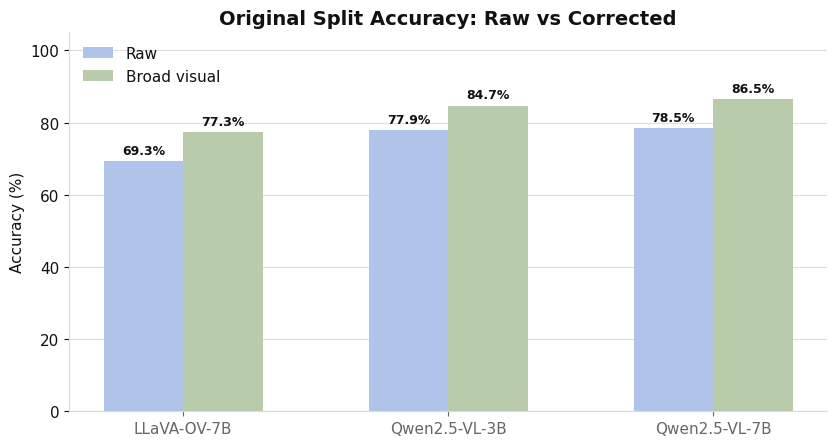

In [9]:
def plot_overall_accuracy():
    plot_df = overall_acc[overall_acc["metric"].isin(["Raw", "Broad visual"])].copy()
    plot_df["model"] = pd.Categorical(plot_df["model"], categories=MODEL_ORDER, ordered=True)
    plot_df = plot_df.sort_values(["model", "metric"])

    models = [m for m in MODEL_ORDER if m in plot_df["model"].astype(str).unique()]
    metrics = ["Raw", "Broad visual"]
    colors = {
        "Raw": REPORT_COLORS["blue"],
        "Broad visual": REPORT_COLORS["green"],
    }

    x = np.arange(len(models))
    width = 0.30

    fig, ax = plt.subplots(figsize=(8.5, 4.6), facecolor="white")
    ax.set_facecolor("white")

    for i, metric in enumerate(metrics):
        vals = (
            plot_df[plot_df["metric"].eq(metric)]
            .set_index("model")
            .reindex(models)["accuracy_pct"]
            .values
        )

        bars = ax.bar(
            x + (i - 0.5) * width,
            vals,
            width,
            color=colors[metric],
            label=metric,
        )

        for bar, val in zip(bars, vals):
            if pd.isna(val):
                continue
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + 1.2,
                f"{val:.1f}%",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
            )

    ax.set_title("Original Split Accuracy: Raw vs Corrected")
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 105)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend(frameon=False)
    clean_axes(ax, grid_axis="y")

    plt.tight_layout()
    save_fig("original_accuracy_raw_vs_corrected_by_model")
    plt.show()


plot_overall_accuracy()


Saved: C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\clean_original_sanity_outputs\figures\original_id_subgroup_accuracy.png


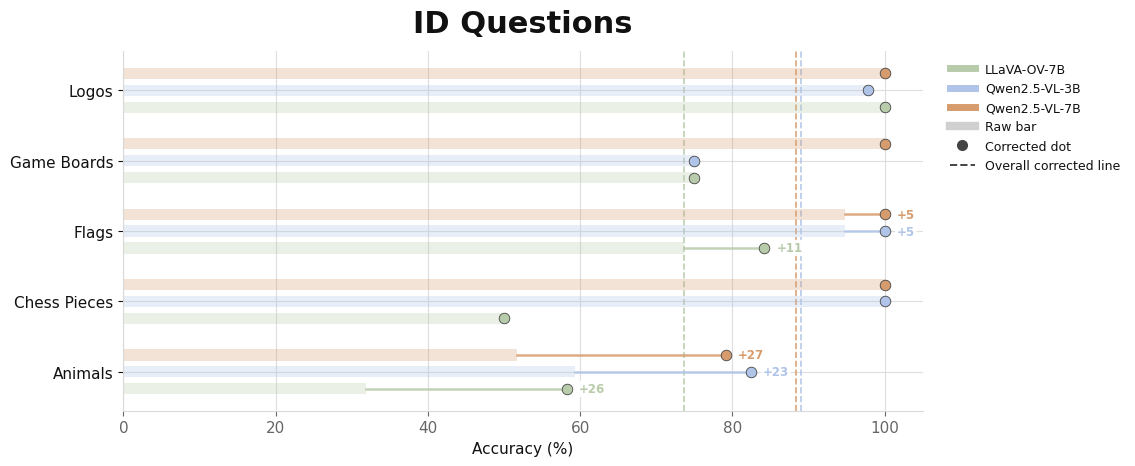

Saved: C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\clean_original_sanity_outputs\figures\original_counting_subgroup_accuracy.png


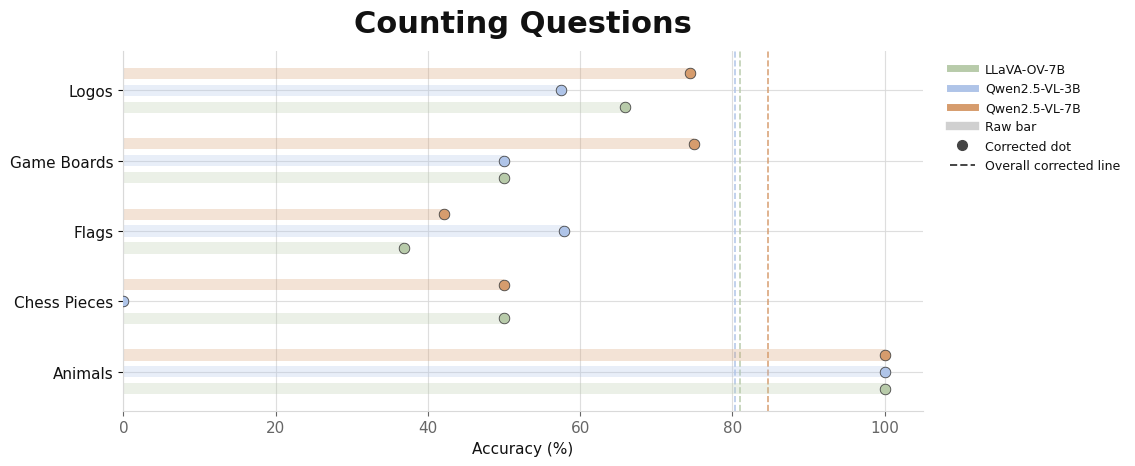

In [10]:
def plot_subgroups(task_name: str):
    df = subgroup_acc[subgroup_acc["task"].eq(task_name)].copy()

    if df.empty:
        print(f"No rows for task: {task_name}")
        return

    topics = ordered_values(df["topic"], DOMAIN_ORDER)
    models = [m for m in MODEL_ORDER if m in df["model"].unique()]

    overall = (
        outputs_eval[outputs_eval["task"].eq(task_name)]
        .groupby("model")["visual_broader_correct"]
        .mean()
        .mul(100)
    )

    y_base = np.arange(len(topics))
    offsets = np.linspace(-0.24, 0.24, len(models))

    fig_h = max(4.8, 0.75 * len(topics))
    fig, ax = plt.subplots(figsize=(11.5, fig_h), facecolor="white")
    ax.set_facecolor("white")

    for model, offset in zip(models, offsets):
        mdf = (
            df[df["model"].eq(model)]
            .set_index("topic")
            .reindex(topics)
        )

        y = y_base + offset
        color = MODEL_COLORS.get(model, REPORT_COLORS["blue"])

        ax.barh(
            y,
            mdf["raw_pct"],
            height=0.16,
            color=color,
            alpha=0.28,
            zorder=2,
        )

        for yi, raw, corrected in zip(y, mdf["raw_pct"], mdf["corrected_pct"]):
            if pd.isna(raw) or pd.isna(corrected):
                continue

            if corrected != raw:
                ax.plot(
                    [raw, corrected],
                    [yi, yi],
                    color=color,
                    alpha=0.85,
                    linewidth=1.8,
                    zorder=3,
                )

        ax.scatter(
            mdf["corrected_pct"],
            y,
            s=58,
            color=color,
            edgecolor=REPORT_COLORS["darkgrey"],
            linewidth=0.6,
            zorder=4,
        )

        for yi, raw, corrected in zip(y, mdf["raw_pct"], mdf["corrected_pct"]):
            if pd.isna(raw) or pd.isna(corrected):
                continue

            delta = corrected - raw
            if delta > 0:
                ax.text(
                    min(corrected + 1.6, 102.5),
                    yi,
                    f"+{delta:.0f}",
                    va="center",
                    ha="left",
                    fontsize=8.5,
                    fontweight="bold",
                    color=color,
                    bbox=dict(
                        boxstyle="round,pad=0.14",
                        facecolor="white",
                        edgecolor="none",
                        alpha=0.95,
                    ),
                    zorder=5,
                )

        if model in overall.index:
            ax.axvline(
                overall.loc[model],
                color=color,
                linestyle="--",
                linewidth=1.2,
                alpha=0.9,
                zorder=1,
            )

    ax.set_yticks(y_base)
    ax.set_yticklabels(topics)
    ax.set_xlim(0, 105)
    ax.set_xlabel("Accuracy (%)")
    ax.set_title(f"{task_name} Questions", fontsize=22, fontweight="bold", pad=14)

    clean_axes(ax, grid_axis="both")

    legend_items = [
        Line2D([0], [0], color=MODEL_COLORS[m], lw=5, label=m)
        for m in models
    ]

    legend_items += [
        Line2D([0], [0], color=REPORT_COLORS["darkgrey"], lw=6, alpha=0.25, label="Raw bar"),
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=REPORT_COLORS["darkgrey"],
            markeredgecolor=REPORT_COLORS["darkgrey"],
            markersize=7,
            label="Corrected dot",
        ),
        Line2D(
            [0], [0],
            color=REPORT_COLORS["darkgrey"],
            linestyle="--",
            lw=1.4,
            label="Overall corrected line",
        ),
    ]

    ax.legend(
        handles=legend_items,
        frameon=False,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=9,
    )

    plt.tight_layout()
    save_fig(f"original_{task_name.lower()}_subgroup_accuracy")
    plt.show()


plot_subgroups("ID")
plot_subgroups("Counting")

## Signal DF

In [11]:
def find_first_existing_column(df: pd.DataFrame, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


def prepare_signals(df: pd.DataFrame) -> pd.DataFrame:
    required = ["type_of_question", "model_answer"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required signal columns: {missing}")

    out = df.copy()

    out["task"] = out["type_of_question"].apply(task_label)
    out["gt_num_eval"] = pd.to_numeric(out.get("ground_truth_num", np.nan), errors="coerce")

    out["pred_num_eval"] = pd.to_numeric(out.get("pred_num", np.nan), errors="coerce").astype(float)
    out["pred_num_eval"] = out["pred_num_eval"].fillna(
        out["model_answer"].apply(extract_number)
    )

    out["proxy_num_eval"] = pd.to_numeric(out.get("proxy_bias_value", np.nan), errors="coerce")

    out["correct_numeric_eval"] = out["pred_num_eval"].eq(out["gt_num_eval"])
    out["proxy_confusion"] = (
        out["pred_num_eval"].eq(out["proxy_num_eval"])
        & ~out["correct_numeric_eval"]
    )

    conditions = [
        out["correct_numeric_eval"],
        out["proxy_confusion"],
        out["pred_num_eval"].notna(),
    ]

    choices = [
        "correct",
        "proxy confusion",
        "other numeric error",
    ]

    out["outcome"] = np.select(
        conditions,
        choices,
        default="non_numeric_or_missing",
    )

    if "prefers_gt_token" in out.columns:
        out["prefers_gt_token"] = out["prefers_gt_token"].fillna(False).astype(bool)
    elif "margin_token" in out.columns:
        out["prefers_gt_token"] = pd.to_numeric(out["margin_token"], errors="coerce") > 0
    else:
        out["prefers_gt_token"] = False

    margin_col = find_first_existing_column(out, ["margin_token", "margin_step", "margin"])
    entropy_col = find_first_existing_column(out, ["entropy_token", "entropy_step", "entropy_step1", "entropy"])

    if margin_col is None:
        raise KeyError("Could not find a signal margin column. Expected one of: margin_token, margin_step, margin")

    out["margin_token"] = pd.to_numeric(out[margin_col], errors="coerce")

    if entropy_col is None:
        out["entropy_token"] = np.nan
    else:
        out["entropy_token"] = pd.to_numeric(out[entropy_col], errors="coerce")

    return out

In [12]:
signals_eval = prepare_signals(signals_raw)

processed_signals_path = OUT_DIR / "original_numeric_signals_all_models_processed.csv"
signals_eval.to_csv(processed_signals_path, index=False)

print("\nSaved processed signal file:")
print(processed_signals_path)

preview_cols = [
    c for c in [
        "model", "ID", "topic", "ground_truth_num", "model_answer",
        "proxy_bias_value", "margin_token", "entropy_token",
        "prefers_gt_token", "outcome"
    ]
    if c in signals_eval.columns
]

display(signals_eval[preview_cols].head())


Saved processed signal file:
C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\clean_original_sanity_outputs\original_numeric_signals_all_models_processed.csv


,model,ID,topic,ground_truth_num,model_answer,proxy_bias_value,margin_token,entropy_token,prefers_gt_token,outcome
0,LLaVA-OV-7B,flag_of_australia_prompt1,Flags,6,7,7,-1.578125,1.481871,False,proxy confusion
1,LLaVA-OV-7B,flag_of_burundi_prompt1,Flags,3,3,4,1.593750,1.068313,True,correct
2,LLaVA-OV-7B,flag_of_china_prompt1,Flags,5,6,6,-0.656250,1.365949,False,proxy confusion
3,LLaVA-OV-7B,flag_of_comoros_prompt1,Flags,4,4,5,0.390625,1.180659,True,correct
4,LLaVA-OV-7B,flag_of_cuba_prompt1,Flags,5,3,3,-4.921875,0.691118,False,proxy confusion


In [13]:
signal_summary = (
    signals_eval
    .groupby("model", as_index=False)
    .agg(
        n=("margin_token", "size"),
        prefers_gt_rate=("prefers_gt_token", "mean"),
        mean_margin=("margin_token", "mean"),
        median_margin=("margin_token", "median"),
        mean_entropy=("entropy_token", "mean"),
        numeric_accuracy=("correct_numeric_eval", "mean"),
        proxy_confusion_rate=("proxy_confusion", "mean"),
    )
)

signal_summary["prefers_gt_pct"] = 100 * signal_summary["prefers_gt_rate"]
signal_summary["numeric_accuracy_pct"] = 100 * signal_summary["numeric_accuracy"]
signal_summary["proxy_confusion_pct"] = 100 * signal_summary["proxy_confusion_rate"]

signal_topic = (
    signals_eval
    .groupby(["model", "topic"], as_index=False)
    .agg(
        n=("margin_token", "size"),
        prefers_gt_pct=("prefers_gt_token", lambda x: 100 * x.mean()),
        mean_margin=("margin_token", "mean"),
        mean_entropy=("entropy_token", "mean"),
        numeric_accuracy_pct=("correct_numeric_eval", lambda x: 100 * x.mean()),
        proxy_confusion_pct=("proxy_confusion", lambda x: 100 * x.mean()),
    )
)

print("\nSignal summary by model:")
display(signal_summary.round(3))

print("\nSignal summary by topic:")
display(signal_topic.round(3))


Signal summary by model:


,model,n,prefers_gt_rate,mean_margin,median_margin,mean_entropy,numeric_accuracy,proxy_confusion_rate,prefers_gt_pct,numeric_accuracy_pct,proxy_confusion_pct
0,LLaVA-OV-7B,154,0.838,4.285,5.828,0.484,0.838,0.143,83.766,83.766,14.286
1,Qwen2.5-VL-3B,153,0.830,4.255,5.875,0.465,0.830,0.150,83.007,83.007,15.033
2,Qwen2.5-VL-7B,154,0.864,7.083,8.641,0.159,0.864,0.123,86.364,86.364,12.338



Signal summary by topic:


,model,topic,n,prefers_gt_pct,mean_margin,mean_entropy,numeric_accuracy_pct,proxy_confusion_pct
0,LLaVA-OV-7B,Animals,91,100.000,6.318,0.061,100.000,0.000
1,LLaVA-OV-7B,Flags,14,35.714,-0.589,1.326,35.714,42.857
2,LLaVA-OV-7B,Game Boards,2,100.000,3.844,0.678,100.000,0.000
3,LLaVA-OV-7B,Logos,47,65.957,1.819,1.044,65.957,34.043
4,Qwen2.5-VL-3B,Animals,91,100.000,6.897,0.051,100.000,0.000
5,Qwen2.5-VL-3B,Flags,14,50.000,0.309,1.045,50.000,35.714
6,Qwen2.5-VL-3B,Game Boards,2,100.000,2.798,0.843,100.000,0.000
7,Qwen2.5-VL-3B,Logos,46,58.696,0.294,1.091,58.696,39.130
8,Qwen2.5-VL-7B,Animals,91,100.000,10.453,0.002,100.000,0.000
9,Qwen2.5-VL-7B,Flags,14,35.714,-0.085,0.753,35.714,50.000


Saved: C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\clean_original_sanity_outputs\figures\original_token_signal_summary_by_model.png


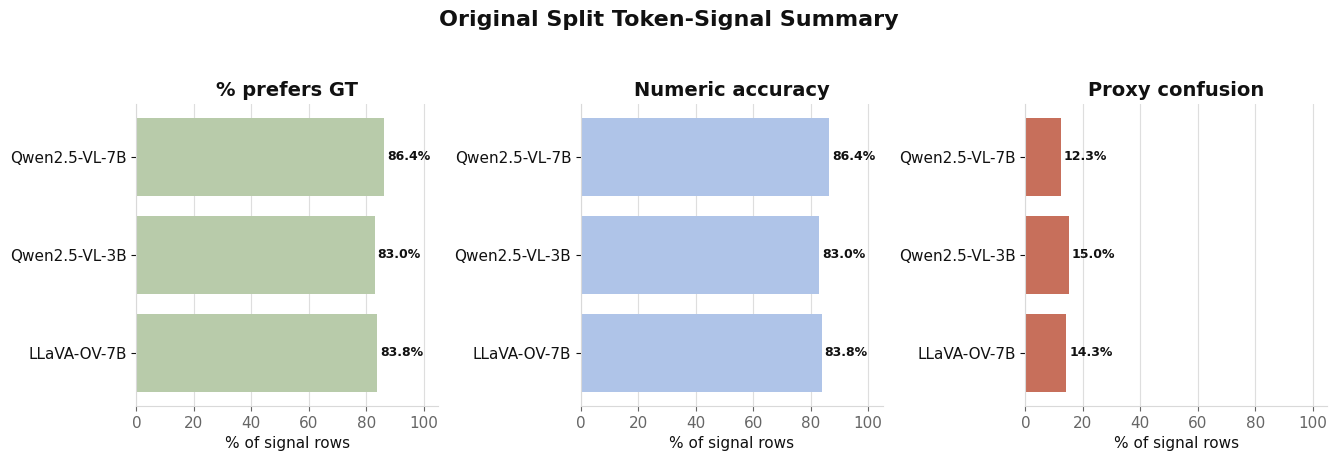

In [14]:
def plot_signal_summary():
    plot_df = signal_summary.copy()
    plot_df["model"] = pd.Categorical(plot_df["model"], categories=MODEL_ORDER, ordered=True)
    plot_df = plot_df.sort_values("model")

    metrics = [
        ("prefers_gt_pct", "% prefers GT", REPORT_COLORS["green"]),
        ("numeric_accuracy_pct", "Numeric accuracy", REPORT_COLORS["blue"]),
        ("proxy_confusion_pct", "Proxy confusion", REPORT_COLORS["red"]),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4), facecolor="white")

    for ax, (col, title, color) in zip(axes, metrics):
        bars = ax.barh(plot_df["model"], plot_df[col], color=color)

        for bar, val in zip(bars, plot_df[col]):
            if pd.isna(val):
                continue
            ax.text(
                val + 1.0,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%",
                va="center",
                fontsize=9,
                fontweight="bold",
            )

        ax.set_title(title)
        ax.set_xlim(0, 105)
        ax.set_xlabel("% of signal rows")
        clean_axes(ax, grid_axis="x")

    fig.suptitle("Original Split Token-Signal Summary", fontsize=16, fontweight="bold", y=1.04)
    plt.tight_layout()
    save_fig("original_token_signal_summary_by_model")
    plt.show()


plot_signal_summary()

Saved: C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\clean_original_sanity_outputs\figures\original_token_outcome_distribution.png


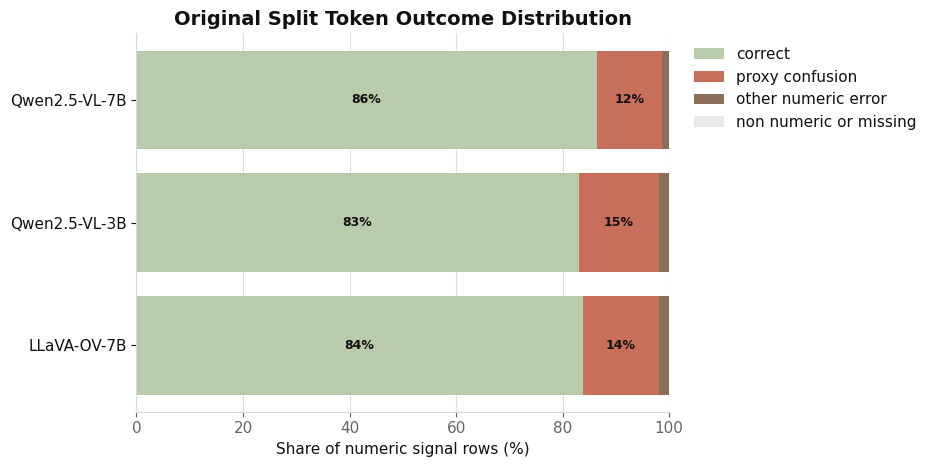

In [15]:
def plot_signal_outcomes():
    outcome_order = [
        "correct",
        "proxy confusion",
        "other numeric error",
        "non_numeric_or_missing",
    ]

    outcome_colors = {
        "correct": REPORT_COLORS["green"],
        "proxy confusion": REPORT_COLORS["red"],
        "other numeric error": REPORT_COLORS["brown"],
        "non_numeric_or_missing": REPORT_COLORS["grey"],
    }

    outcome_counts = (
        signals_eval
        .groupby(["model", "outcome"])
        .size()
        .reset_index(name="n")
    )

    outcome_counts["pct"] = (
        100
        * outcome_counts["n"]
        / outcome_counts.groupby("model")["n"].transform("sum")
    )

    outcome_pivot = (
        outcome_counts
        .pivot(index="model", columns="outcome", values="pct")
        .reindex(index=MODEL_ORDER)
        .reindex(columns=outcome_order)
        .fillna(0)
    )

    fig, ax = plt.subplots(figsize=(9.5, 4.8), facecolor="white")

    left = np.zeros(len(outcome_pivot))

    for outcome in outcome_order:
        vals = outcome_pivot[outcome].values

        ax.barh(
            outcome_pivot.index,
            vals,
            left=left,
            color=outcome_colors[outcome],
            label=outcome.replace("_", " "),
        )

        for yi, start, val in zip(range(len(outcome_pivot)), left, vals):
            if val >= 7:
                ax.text(
                    start + val / 2,
                    yi,
                    f"{val:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    fontweight="bold",
                )

        left += vals

    ax.set_title("Original Split Token Outcome Distribution")
    ax.set_xlabel("Share of numeric signal rows (%)")
    ax.set_xlim(0, 100)
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    clean_axes(ax, grid_axis="x")

    plt.tight_layout()
    save_fig("original_token_outcome_distribution")
    plt.show()


plot_signal_outcomes()


Saved: C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\clean_original_sanity_outputs\figures\original_token_entropy_vs_margin.png


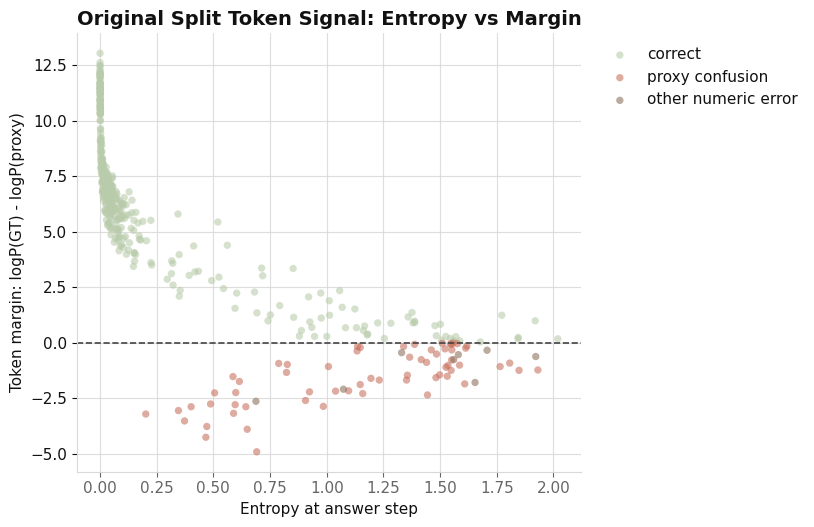

In [16]:
def plot_margin_entropy():
    if signals_eval["entropy_token"].notna().sum() == 0:
        print("Skipping margin vs entropy plot: entropy_token is missing for all rows.")
        return

    outcome_order = [
        "correct",
        "proxy confusion",
        "other numeric error",
        "non_numeric_or_missing",
    ]

    outcome_colors = {
        "correct": REPORT_COLORS["green"],
        "proxy confusion": REPORT_COLORS["red"],
        "other numeric error": REPORT_COLORS["brown"],
        "non_numeric_or_missing": REPORT_COLORS["grey"],
    }

    scatter_df = signals_eval.dropna(subset=["margin_token", "entropy_token"]).copy()

    if scatter_df.empty:
        print("Skipping margin vs entropy plot: no rows with both margin and entropy.")
        return

    fig, ax = plt.subplots(figsize=(8.3, 5.4), facecolor="white")

    for outcome in outcome_order:
        tmp = scatter_df[scatter_df["outcome"].eq(outcome)]
        if tmp.empty:
            continue

        ax.scatter(
            tmp["entropy_token"],
            tmp["margin_token"],
            s=28,
            alpha=0.58,
            color=outcome_colors[outcome],
            label=outcome.replace("_", " "),
            edgecolor="none",
        )

    ax.axhline(0, color=REPORT_COLORS["darkgrey"], linestyle="--", linewidth=1.2)
    ax.set_title("Original Split Token Signal: Entropy vs Margin")
    ax.set_xlabel("Entropy at answer step")
    ax.set_ylabel("Token margin: logP(GT) - logP(proxy)")
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    clean_axes(ax, grid_axis="both")

    plt.tight_layout()
    save_fig("original_token_entropy_vs_margin")
    plt.show()


plot_margin_entropy()

Saved: C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\clean_original_sanity_outputs\figures\original_entropy_margin_model_panels.png


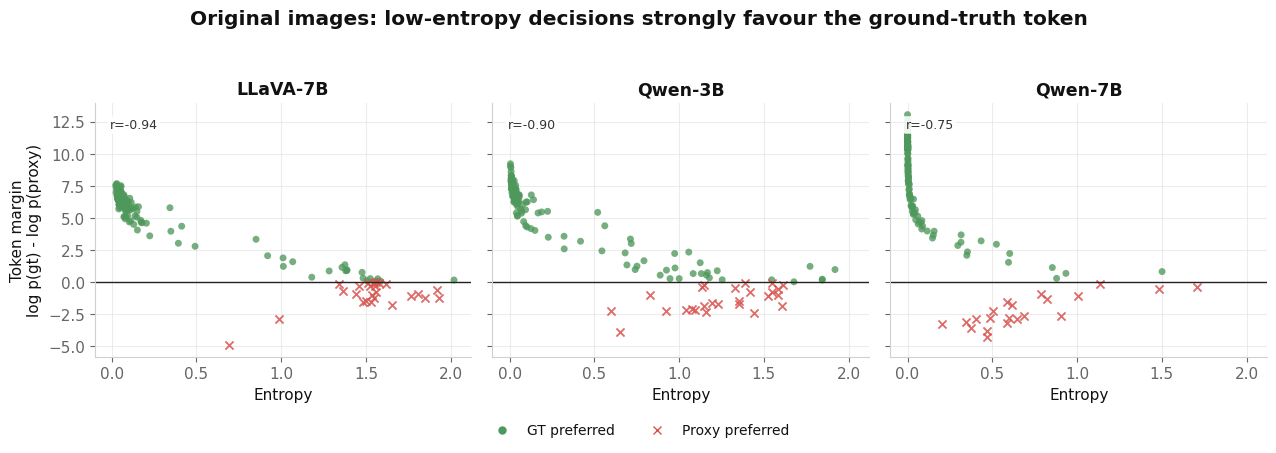

In [17]:
from scipy.stats import pearsonr

MODEL_SHORT = {
    "LLaVA-OV-7B": "LLaVA-7B",
    "Qwen2.5-VL-3B": "Qwen-3B",
    "Qwen2.5-VL-7B": "Qwen-7B",
}

PREFERENCE_COLORS = {
    "GT preferred": "#4F985B",
    "Proxy preferred": "#D9534F",
}

def plot_entropy_margin_panels():
    df = signals_eval.dropna(subset=["margin_token", "entropy_token"]).copy()

    if df.empty:
        print("No rows with both margin_token and entropy_token.")
        return

    df["preference"] = np.where(
        df["margin_token"] > 0,
        "GT preferred",
        "Proxy preferred",
    )

    models = [m for m in MODEL_ORDER if m in df["model"].unique()]
    if not models:
        models = sorted(df["model"].dropna().unique())

    fig, axes = plt.subplots(
        1,
        len(models),
        figsize=(4.3 * len(models), 3.9),
        sharex=True,
        sharey=True,
        facecolor="white",
    )

    if len(models) == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        sub = df[df["model"].eq(model)].copy()

        for preference in ["GT preferred", "Proxy preferred"]:
            part = sub[sub["preference"].eq(preference)]
            if part.empty:
                continue

            if preference == "GT preferred":
                ax.scatter(
                    part["entropy_token"],
                    part["margin_token"],
                    s=25,
                    alpha=0.78,
                    color=PREFERENCE_COLORS[preference],
                    edgecolor="none",
                    label=preference,
                )
            else:
                ax.scatter(
                    part["entropy_token"],
                    part["margin_token"],
                    s=34,
                    alpha=0.85,
                    marker="x",
                    color=PREFERENCE_COLORS[preference],
                    linewidth=1.3,
                    label=preference,
                )

        ax.axhline(0, color="#222222", linewidth=1.0)
        ax.set_title(MODEL_SHORT.get(model, model), fontsize=12.5, fontweight="bold")
        ax.set_xlabel("Entropy")

        if len(sub) >= 3 and sub["entropy_token"].nunique() > 1 and sub["margin_token"].nunique() > 1:
            r, _ = pearsonr(sub["entropy_token"], sub["margin_token"])
            ax.text(
                0.04,
                0.90,
                f"r={r:.2f}",
                transform=ax.transAxes,
                fontsize=9,
                color="#333333",
                bbox=dict(
                    boxstyle="round,pad=0.18",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.9,
                ),
            )

        ax.grid(color="#E6E6E6", linewidth=0.75, alpha=0.75)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("#D0D0D0")
        ax.spines["bottom"].set_color("#D0D0D0")

    axes[0].set_ylabel("Token margin\nlog p(gt) - log p(proxy)")

    fig.suptitle(
        "Original images: low-entropy decisions strongly favour the ground-truth token",
        fontsize=14.5,
        fontweight="bold",
        y=1.05,
    )

    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=PREFERENCE_COLORS["GT preferred"],
            markeredgecolor="none",
            markersize=6,
            label="GT preferred",
        ),
        Line2D(
            [0],
            [0],
            marker="x",
            color=PREFERENCE_COLORS["Proxy preferred"],
            markersize=6,
            linestyle="None",
            label="Proxy preferred",
        ),
    ]

    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, -0.08),
        fontsize=10,
    )

    plt.tight_layout()
    save_fig("original_entropy_margin_model_panels")
    plt.show()


plot_entropy_margin_panels()

In [18]:
paper_accuracy = (
    overall_acc
    .pivot(index="model", columns="metric", values="accuracy_pct")
    .reset_index()
)

paper_signal = signal_summary[
    [
        "model",
        "n",
        "prefers_gt_pct",
        "numeric_accuracy_pct",
        "proxy_confusion_pct",
        "mean_margin",
        "median_margin",
        "mean_entropy",
    ]
].copy()

In [ ]:
paper_accuracy

metric,model,Broad visual,Raw,Strict corrected
0,LLaVA-OV-7B,77.300613,69.325153,71.165644
1,Qwen2.5-VL-3B,84.662577,77.914110,80.368098
2,Qwen2.5-VL-7B,86.503067,78.527607,80.981595


In [ ]:
paper_signal

,model,n,prefers_gt_pct,numeric_accuracy_pct,proxy_confusion_pct,mean_margin,median_margin,mean_entropy
0,LLaVA-OV-7B,154,83.766234,83.766234,14.285714,4.284852,5.828125,0.484082
1,Qwen2.5-VL-3B,153,83.006536,83.006536,15.032680,4.255408,5.875000,0.464562
2,Qwen2.5-VL-7B,154,86.363636,86.363636,12.337662,7.082671,8.640625,0.159236
